# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Sumber dataset : https://www.kaggle.com/datasets/yakdemir/movie-feelings-emotion-features-for-1500-films  
Deskripsi Projek :
Dataset ini berisi daftar film beserta skor fitur mood/feelings (seperti f1_sadness, f1_joy, f1_fear) yang diekstrak dari plot film. Tujuan eksperimen ini adalah untuk membangun sistem rekomendasi Content-Based Filtering menggunakan kemiripan Cosine (Cosine Similarity).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
df_movies = pd.read_csv('../dataset_raw/movie_feelings_dataset.csv')
df_synonyms = pd.read_csv('../dataset_raw/synonyms_of_feelings.csv')

In [4]:
df_movies.head()

,imdb_id,title,year,title_year,plot,imdb_rating,tomatometer,metascore,avg_rating,f1_skepticism,...,f3_curiosity,f3_regret,f3_nostalgia,f3_irony,f3_despair,f3_resignation,f3_closeness,f3_adrenaline,f3_belonging,f3_anger
0,tt8579674,1917,2019,1917 (2019),"April 1917, the Western Front. Two British sol...",82,88.0,78.0,82.50,0.005703,...,0,0,0,0,0,0,0,0,0,0
1,tt1022603,(500) Days of Summer,2009,(500) Days of Summer (2009),After it looks as if she's left his life for g...,77,86.0,76.0,79.00,0.005997,...,0,1,0,0,0,0,0,0,0,0
2,tt1179933,10 Cloverfield Lane,2016,10 Cloverfield Lane (2016),"After getting in a car accident, Michelle awak...",72,91.0,76.0,77.75,0.038889,...,0,0,0,0,0,0,0,0,0,0
3,tt0050083,12 Angry Men,1957,12 Angry Men (1957),"The defense and the prosecution have rested, a...",90,100.0,97.0,94.25,0.021538,...,0,0,0,0,0,0,0,0,0,0
4,tt0114746,12 Monkeys,1995,Twelve Monkeys (1995),"James Cole, a prisoner of the state in the yea...",80,88.0,75.0,80.75,0.016173,...,0,0,0,0,1,0,0,0,0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

1. Inspeksi Struktur Data Dasar

In [5]:
print(f"Dimensi Dataset : {df_movies.shape}")

Dimensi Dataset : (1500, 161)


In [6]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Columns: 161 entries, imdb_id to f3_anger
dtypes: float64(53), int64(102), object(6)
memory usage: 1.8+ MB


In [7]:
df_movies.head(5)

,imdb_id,title,year,title_year,plot,imdb_rating,tomatometer,metascore,avg_rating,f1_skepticism,...,f3_curiosity,f3_regret,f3_nostalgia,f3_irony,f3_despair,f3_resignation,f3_closeness,f3_adrenaline,f3_belonging,f3_anger
0,tt8579674,1917,2019,1917 (2019),"April 1917, the Western Front. Two British sol...",82,88.0,78.0,82.50,0.005703,...,0,0,0,0,0,0,0,0,0,0
1,tt1022603,(500) Days of Summer,2009,(500) Days of Summer (2009),After it looks as if she's left his life for g...,77,86.0,76.0,79.00,0.005997,...,0,1,0,0,0,0,0,0,0,0
2,tt1179933,10 Cloverfield Lane,2016,10 Cloverfield Lane (2016),"After getting in a car accident, Michelle awak...",72,91.0,76.0,77.75,0.038889,...,0,0,0,0,0,0,0,0,0,0
3,tt0050083,12 Angry Men,1957,12 Angry Men (1957),"The defense and the prosecution have rested, a...",90,100.0,97.0,94.25,0.021538,...,0,0,0,0,0,0,0,0,0,0
4,tt0114746,12 Monkeys,1995,Twelve Monkeys (1995),"James Cole, a prisoner of the state in the yea...",80,88.0,75.0,80.75,0.016173,...,0,0,0,0,1,0,0,0,0,0


**Interpretasi Hasil Inspeksi Struktur Data:**

Berdasarkan *output* di atas, kita bisa mengambil beberapa kesimpulan awal terkait struktur dataset:
* Dataset memiliki total **1.500 baris** (mewakili jumlah film) dan **161 kolom**. Jumlah kolom yang banyak ini wajar karena dataset menyimpan ratusan skor fitur *mood/feelings* (seperti `f3_anger`, dll).
* Terdapat tiga jenis tipe data di dalam dataset ini: **53 kolom float64** (angka desimal), **102 kolom int64** (angka bulat), dan **6 kolom object** (biasanya berupa teks atau *string* seperti ID dan judul film).
* Mayoritas kolom (155 kolom) sudah berbentuk numerik. Hal ini sangat menguntungkan karena fitur emosi sudah dalam format angka yang siap diproses untuk perhitungan jarak kemiripan (*Cosine Similarity*) tanpa perlu banyak konversi tipe data tambahan.
* Ukuran memori dataset ini juga relatif kecil (sekitar 1.8 MB), sehingga masih sangat aman untuk diproses langsung di *memory* lokal tanpa kendala performa.

2. Pengecekan Kualitas Data

In [8]:
# Mengecek Missing Value
print("Missing Value pada Dataset :")
print(df_movies.isnull().sum().sort_values(ascending=False))

Missing Value pada Dataset :
metascore         169
f1_excitement      27
f1_envy            27
f1_elation         27
f1_solidarity      27
                 ... 
f3_resignation      0
f3_closeness        0
f3_adrenaline       0
f3_belonging        0
f3_anger            0
Length: 161, dtype: int64


In [9]:
# Mengecek data duplikat
print("Jumlah Data Duplikat : ", df_movies.duplicated().sum())

Jumlah Data Duplikat :  0


**Interpretasi Hasil Pengecekan Kualitas Data:**

Berdasarkan pengecekan *missing value* dan data duplikat, diperoleh informasi berikut:
* **Data Duplikat:** Tidak ditemukan adanya baris data yang duplikat (0). Setiap baris sudah merepresentasikan satu film yang unik dan siap diproses.
* **Missing Value (Data Kosong):** Terdapat beberapa nilai kosong (NaN/Null) yang terdeteksi:
    * Kolom `metascore` memiliki 169 data kosong. Karena model *Content-Based Filtering* kita berfokus pada fitur emosi, kolom metadata pendukung seperti `metascore` tidak akan digunakan dalam perhitungan kemiripan (*Cosine Similarity*), sehingga bisa diabaikan atau dibuang pada tahap preprocessing.
    * Terdapat 27 baris data kosong pada beberapa kolom fitur emosi (seperti `f1_excitement`, `f1_envy`, `f1_elation`, dll). Agar tidak menyebabkan *error* saat perhitungan matematika pada model, nilai kosong ini akan diisi (imputasi) dengan nilai `0.0` di tahap preprocessing. Asumsinya, nilai kosong berarti film tersebut tidak memiliki muatan emosi yang bersangkutan.

3. Analisis Statistik Deskriptif Skor Mood

In [10]:
# Statistik Deskriptif untuk Kolom dengan Prefix 'f1_'
kolom_f1 = [col for col in df_movies.columns if col.startswith('f1_')]

print("Statistik Deskriptif untuk Kolom dengan Prefix 'f1_' :")
display(df_movies[kolom_f1].describe())

Statistik Deskriptif untuk Kolom dengan Prefix 'f1_' :


,f1_skepticism,f1_serenity,f1_fear,f1_disgust,f1_solidarity,f1_elation,f1_envy,f1_puzzlement,f1_recklessness,f1_loyalty,...,f1_curiosity,f1_regret,f1_nostalgia,f1_irony,f1_despair,f1_resignation,f1_closeness,f1_adrenaline,f1_belonging,f1_anger
count,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,...,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000
mean,0.012039,0.004594,0.087296,0.019376,0.079651,0.068249,0.058406,0.011010,0.005217,0.018534,...,0.039918,0.056375,0.017190,0.018244,0.021071,0.002695,0.020925,0.002572,0.003516,0.250734
std,0.019276,0.016202,0.094677,0.027448,0.048739,0.057907,0.031554,0.014871,0.014044,0.021417,...,0.031228,0.032949,0.024555,0.016491,0.032654,0.008229,0.048010,0.009803,0.005308,0.101037
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.003472,0.000000,0.031250,0.005780,0.050258,0.031646,0.039855,0.003036,0.000000,0.005639,...,0.018939,0.036745,0.003601,0.007764,0.004506,0.000000,0.005747,0.000000,0.000000,0.193931
50%,0.007752,0.001885,0.052239,0.012448,0.070312,0.053333,0.054054,0.007331,0.002762,0.012085,...,0.032000,0.051471,0.009585,0.014286,0.012048,0.000000,0.012308,0.000000,0.002140,0.246753
75%,0.014006,0.005357,0.105500,0.023753,0.098790,0.085482,0.071804,0.013333,0.006250,0.024885,...,0.053446,0.072874,0.022059,0.024194,0.026042,0.003033,0.022472,0.002525,0.005013,0.304348
max,0.333333,0.557872,0.649034,0.358108,0.573317,0.508772,0.299223,0.247140,0.456522,0.333333,...,0.214286,0.333333,0.333333,0.158730,0.545249,0.162791,0.933440,0.281905,0.071429,0.747664


In [11]:
# Statistik Deskriptif untuk Kolom dengan Prefix 'f2_'
kolom_f2 = [col for col in df_movies.columns if col.startswith('f2_')]

print("Statistik Deskriptif untuk Kolom dengan Prefix 'f2_' :")
display(df_movies[kolom_f2].describe())

Statistik Deskriptif untuk Kolom dengan Prefix 'f2_' :


,f2_skepticism,f2_serenity,f2_fear,f2_disgust,f2_solidarity,f2_elation,f2_envy,f2_puzzlement,f2_recklessness,f2_loyalty,...,f2_curiosity,f2_regret,f2_nostalgia,f2_irony,f2_despair,f2_resignation,f2_closeness,f2_adrenaline,f2_belonging,f2_anger
count,1500.00000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,...,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.0,1500.000000,1500.0,1500.000000,1500.000000
mean,0.03400,0.002000,0.03400,0.006000,0.032000,0.004667,0.005333,0.132667,0.058667,0.070667,...,0.014667,0.009333,0.004667,0.192667,0.036667,0.0,0.022000,0.0,0.160667,0.037333
std,0.18129,0.044692,0.18129,0.077253,0.176059,0.068176,0.072859,0.339327,0.235078,0.256353,...,0.120255,0.096189,0.068176,0.394525,0.188005,0.0,0.146732,0.0,0.367346,0.189641
min,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
25%,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
50%,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
75%,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
max,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,0.0,1.000000,1.000000


In [12]:
# Statistik Deskriptif untuk Kolom dengan Prefix 'f3_'
kolom_f3 = [col for col in df_movies.columns if col.startswith('f3_')]

print("Statistik Deskriptif untuk Kolom dengan Prefix 'f3_' :")
display(df_movies[kolom_f3].describe())

Statistik Deskriptif untuk Kolom dengan Prefix 'f3_' :


,f3_skepticism,f3_serenity,f3_fear,f3_disgust,f3_solidarity,f3_elation,f3_envy,f3_puzzlement,f3_recklessness,f3_loyalty,...,f3_curiosity,f3_regret,f3_nostalgia,f3_irony,f3_despair,f3_resignation,f3_closeness,f3_adrenaline,f3_belonging,f3_anger
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.0,1500.000000,1500.000000,1500.000000,1500.000000,...,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.0,1500.000000,1500.000000,1500.000000
mean,0.020000,0.009333,0.205333,0.008000,0.006667,0.0,0.001333,0.106667,0.010000,0.000667,...,0.052000,0.064000,0.056000,0.107333,0.103333,0.054667,0.0,0.004667,0.128667,0.016000
std,0.140047,0.096189,0.404080,0.089114,0.081404,0.0,0.036503,0.308792,0.099532,0.025820,...,0.222101,0.244835,0.229998,0.309640,0.304495,0.227404,0.0,0.068176,0.334942,0.125517
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000


**Interpretasi Hasil Statistik Deskriptif Fitur Mood:**

Berdasarkan pengecekan distribusi nilai pada fitur mood, ditemukan beberapa karakteristik:
* **Fitur Level 2 (`f2_`) dan Level 3 (`f3_`):** Memiliki rentang skala nilai yang sudah ternormalisasi sempurna, yaitu dari minimum 0.0 hingga maksimum 1.0. Tidak ada *missing value* (count = 1500).
* **Fitur Level 1 (`f1_`):** Memiliki nilai minimum 0.0, namun nilai maksimum bervariasi (rata-rata di bawah 1.0). Terdapat *missing value* (count = 1473).
* Secara keseluruhan, karena seluruh fitur sudah berada dalam format rasio desimal yang kecil (bukan skala puluhan atau ratusan), data ini **sudah layak** dan aman untuk langsung digunakan dalam perhitungan jarak *Cosine Similarity* tanpa perlu dilakukan tahap *scaling* atau *normalization* tambahan yang berlebihan.

4. Visualisasi Top 10 Mood Dominan

/tmp/ipykernel_238059/923227529.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_mood_f1.values, y=top_10_mood_f1.index, palette='viridis')


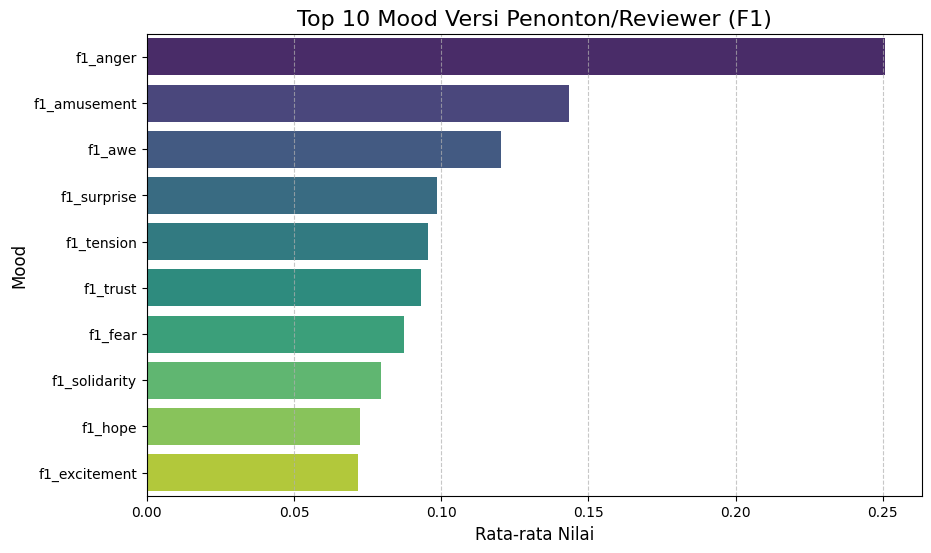

In [13]:
# Visualisasi Top 10 Mood Versi Penonton/Reviwer (F1)
mood_f1_mean = df_movies[kolom_f1].mean().sort_values(ascending=False)

top_10_mood_f1 = mood_f1_mean.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_mood_f1.values, y=top_10_mood_f1.index, palette='viridis')


plt.title('Top 10 Mood Versi Penonton/Reviewer (F1)', fontsize=16)
plt.xlabel('Rata-rata Nilai', fontsize=12)
plt.ylabel('Mood', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

/tmp/ipykernel_238059/1791050158.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_mood_f2.values, y=top_10_mood_f2.index, palette='magma')


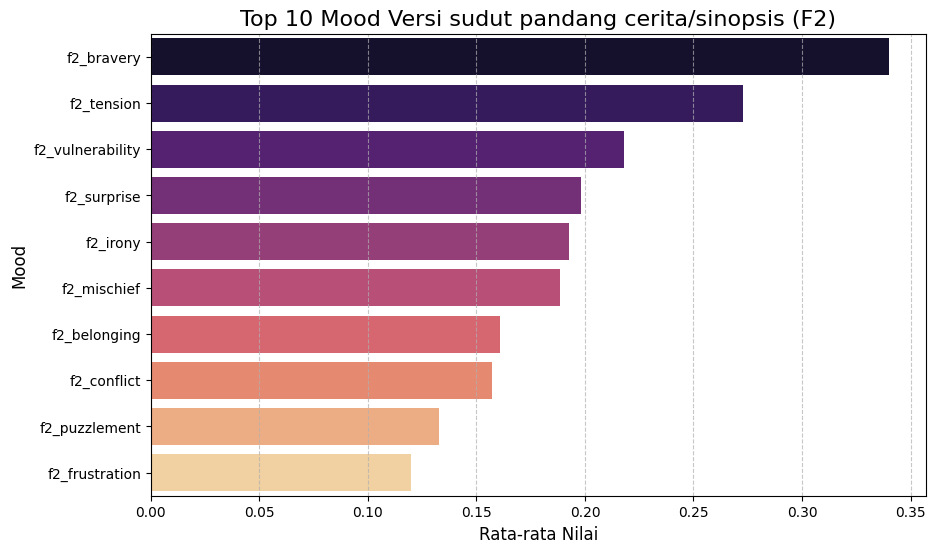

In [14]:
# Visualisasi Top 10 Mood Versi sudut pandang cerita/sinopsis
mood_f2_mean = df_movies[kolom_f2].mean().sort_values(ascending=False)

top_10_mood_f2 = mood_f2_mean.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_mood_f2.values, y=top_10_mood_f2.index, palette='magma')


plt.title('Top 10 Mood Versi sudut pandang cerita/sinopsis (F2)', fontsize=16)
plt.xlabel('Rata-rata Nilai', fontsize=12)
plt.ylabel('Mood', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

/tmp/ipykernel_238059/4077904744.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_mood_f3.values, y=top_10_mood_f3.index, palette='cividis')


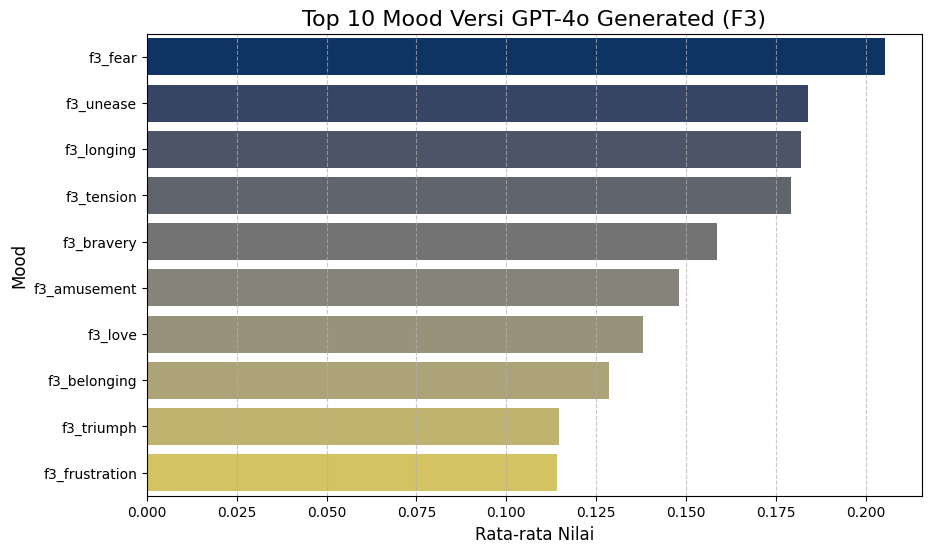

In [15]:
# Visualisasi Top 10 Mood Versi GPT-4o Generated
mood_f3_mean = df_movies[kolom_f3].mean().sort_values(ascending=False)

top_10_mood_f3 = mood_f3_mean.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_mood_f3.values, y=top_10_mood_f3.index, palette='cividis')


plt.title('Top 10 Mood Versi GPT-4o Generated (F3)', fontsize=16)
plt.xlabel('Rata-rata Nilai', fontsize=12)
plt.ylabel('Mood', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

**Interpretasi Insight Top 10 Mood Berdasarkan Sumber Ekstraksi:**

Berdasarkan visualisasi dari ketiga sumber data emosi (F1, F2, dan F3), terdapat perbedaan menarik dalam cara masing-masing metode menangkap mood dominan dari sebuah film:

1. Perspektif Penonton/Reviewer (F1 - Teks Ulasan)

    Mood yang paling mendominasi adalah Anger (marah) dan Amusement (hiburan/kesenangan).

    Hal ini menunjukkan bahwa penonton cenderung lebih vokal dan ekspresif dalam menulis review ketika sebuah film berhasil memancing emosi negatif yang kuat (marah) atau ketika film tersebut sangat menghibur (amusement). Emosi seperti Awe (kagum) dan Surprise (terkejut) juga tinggi, menandakan penonton sering menyoroti plot twist atau kualitas visual/cerita yang luar biasa.

2. Perspektif Plot Cerita (F2 - Model AI Transformer)

    Berdasarkan ekstraksi dari sinopsis murni, mood tertinggi adalah Bravery (keberanian) dan Tension (ketegangan).

    Ini sangat logis karena struktur dasar sinopsis film (terutama genre Action, Thriller, atau Drama) biasanya berpusat pada konflik utama, di mana tokoh utama harus menunjukkan keberanian (bravery) untuk menghadapi situasi yang penuh ketegangan (tension) atau kerentanan (vulnerability).

3. Perspektif LLM (F3 - GPT-4o)

    AI generatif (GPT-4o) mendeteksi Fear (rasa takut) dan Unease (kegelisahan) sebagai mood yang paling kuat secara keseluruhan, disusul oleh Longing (kerinduan).

    GPT-4o tampaknya lebih sensitif dalam menangkap nuansa emosi psikologis atau subtext (makna tersirat) dari sebuah film dibandingkan model ekstraksi lainnya, mengelompokkan film-film ini ke dalam tema-tema kecemasan dan kerinduan emosional.

5. Visualisasi Korelasi Antar Emosi Dominan

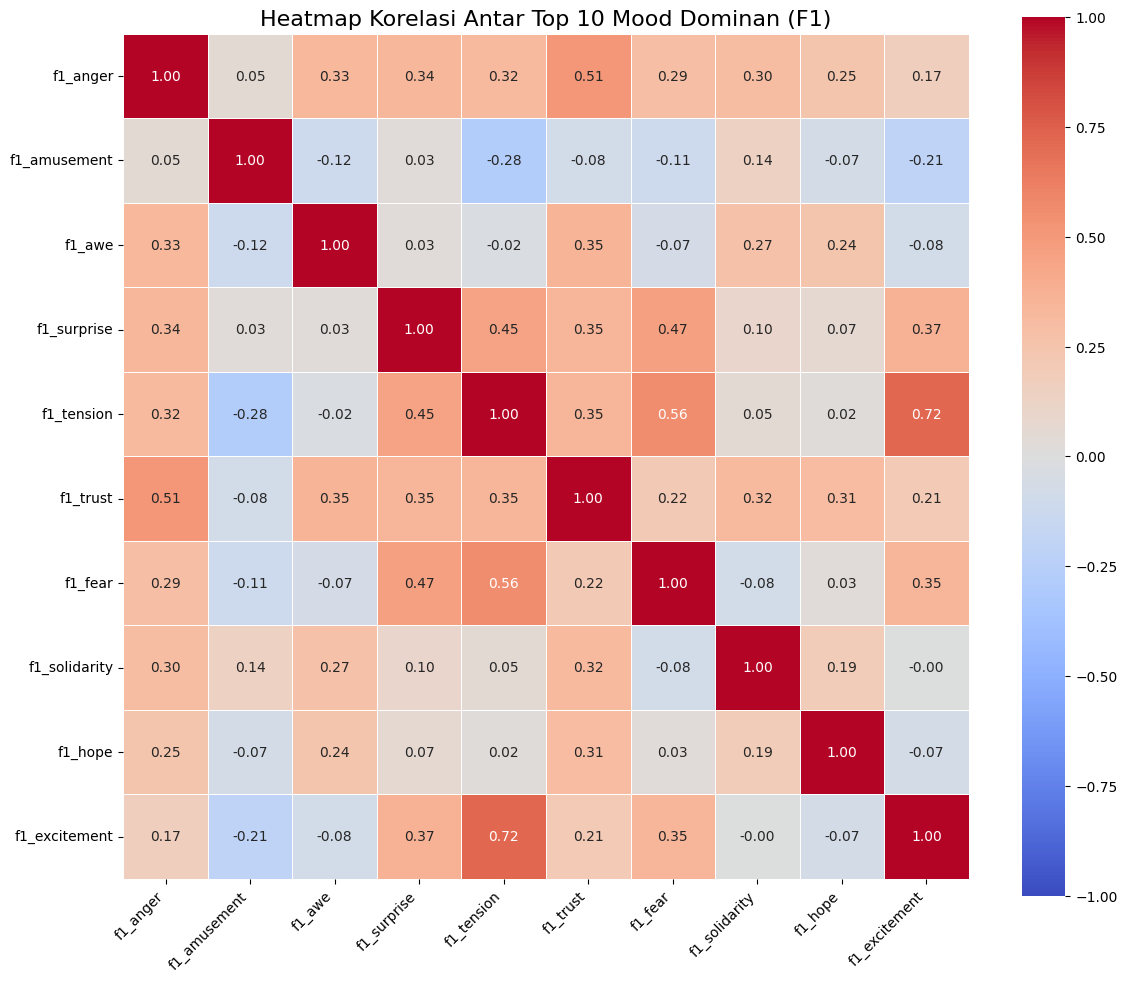

In [16]:
top_10_mood_f1_cols = top_10_mood_f1.index.tolist()

corr_matrix_f1 = df_movies[top_10_mood_f1_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_f1, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, square=True)

plt.title('Heatmap Korelasi Antar Top 10 Mood Dominan (F1)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.show()


**Interpretasi Insight Heatmap Korelasi:**

Visualisasi heatmap di atas menunjukkan korelasi Pearson antara 10 fitur *mood* paling dominan dari sudut pandang penonton (F1). Dari matriks tersebut, ditemukan beberapa hubungan yang sangat logis:
* **Korelasi Positif Kuat:** Terdapat hubungan yang sangat kuat antara **Tension & Excitement (0.72)**, serta **Tension & Fear (0.56)**. Hal ini sangat masuk akal karena film bergenre *Action*, *Thriller*, atau *Horror* umumnya memadukan elemen ketegangan, pacuan adrenalin, dan rasa takut secara bersamaan. Ada juga korelasi lumayan antara **Fear & Surprise (0.47)** yang identik dengan elemen *jump-scare*.
* **Korelasi Negatif/Lemah:** Fitur **Amusement** (hiburan/komedi) memiliki korelasi negatif dengan **Tension (-0.28)** dan **Excitement (-0.21)**. Ini membuktikan bahwa film dengan unsur komedi yang kental jarang sekali mencampuradukkan plotnya dengan ketegangan yang intens.
* **Kesimpulan:** Insight ini memvalidasi kualitas ekstraksi dataset. Fitur emosi yang saling mendukung secara logis ini akan membuat perhitungan kemiripan jarak pada model *Content-Based Filtering* kita menjadi jauh lebih presisi dan masuk akal.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Membuang fitur / kolom yang tidak digunakan

In [17]:
df_clean = df_movies.copy()

kolom_dibuang = [
    'title', 'year', 'plot', 'imdb_rating', 
    'tomatometer', 'metascore', 'avg_rating', 
    'plot_feelings', 'gpt_feelings'
]

df_clean.drop(columns=kolom_dibuang, inplace=True)

print(f"Dimensi data setelah preprocessing: {df_clean.shape}")

Dimensi data setelah preprocessing: (1500, 152)


Mengatasi data null pada kolom f1

In [18]:
df_clean.fillna(0, inplace=True)
print(f"Total missing value tersisa: {df_clean.isnull().sum().sum()}")

Total missing value tersisa: 0


In [19]:
display(df_clean.head(3))

,imdb_id,title_year,f1_skepticism,f1_serenity,f1_fear,f1_disgust,f1_solidarity,f1_elation,f1_envy,f1_puzzlement,...,f3_curiosity,f3_regret,f3_nostalgia,f3_irony,f3_despair,f3_resignation,f3_closeness,f3_adrenaline,f3_belonging,f3_anger
0,tt8579674,1917 (2019),0.005703,0.001901,0.044043,0.005070,0.044994,0.016160,0.027883,0.004753,...,0,0,0,0,0,0,0,0,0,0
1,tt1022603,(500) Days of Summer (2009),0.005997,0.001499,0.023988,0.007496,0.128936,0.377811,0.076462,0.010495,...,0,1,0,0,0,0,0,0,0,0
2,tt1179933,10 Cloverfield Lane (2016),0.038889,0.000926,0.144444,0.009259,0.082407,0.065741,0.041667,0.020370,...,0,0,0,0,0,0,0,0,0,0


Save Dataset Hasil Pre-processing

In [20]:
df_clean.to_csv('dataset_preprocessing/movie_feelings_dataset_preprocessing.csv', index=False)

print('data berhasil disimpan')

data berhasil disimpan
